In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('../data/OnlineRetail.csv', encoding='latin1')
df_map = pd.read_excel('../data/rfm_mapping.xlsx')

In [3]:
df = data.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.duplicated().sum()

np.int64(5268)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype("str")

In [9]:
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].reset_index(drop=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  object 
 7   Country      392692 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 24.0+ MB


In [11]:
frequency_df = df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
frequency_df.rename(columns={"InvoiceNo":"Frequency"},inplace=True)
frequency_df.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [12]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [13]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
recency_df = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
recency_df["Recency"] = (reference_date - recency_df["InvoiceDate"]).dt.days
recency_df = recency_df.drop("InvoiceDate",axis=1)
recency_df.head()

,CustomerID,Recency
0,12346.0,326
1,12347.0,2
2,12348.0,75
3,12349.0,19
4,12350.0,310


In [14]:
df["Monetary"] = df["UnitPrice"] * df ["Quantity"]
monetary_df = df.groupby("CustomerID")["Monetary"].sum().reset_index()
monetary_df.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [15]:
recency_df = recency_df.merge(frequency_df,on = "CustomerID")
df_rfm = recency_df.merge(monetary_df,on = "CustomerID")
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [16]:
customer_country = df.groupby('CustomerID')['Country'].first().reset_index()

df_rfm = df_rfm.merge(customer_country, on='CustomerID', how='left')

df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,Country
0,12346.0,326,1,77183.60,United Kingdom
1,12347.0,2,7,4310.00,Iceland
2,12348.0,75,4,1797.24,Finland
3,12349.0,19,1,1757.55,Italy
4,12350.0,310,1,334.40,Norway


In [17]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   object 
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
 4   Country     4338 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 169.6+ KB


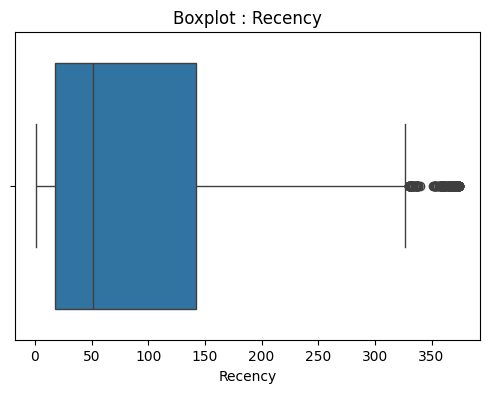

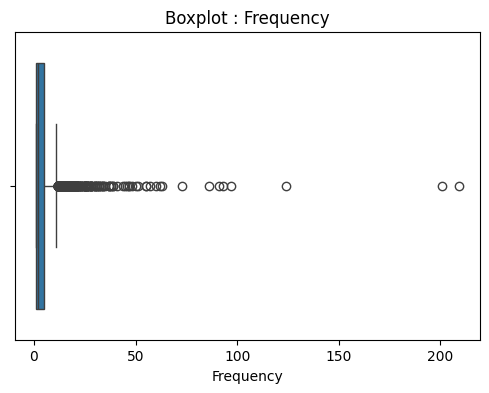

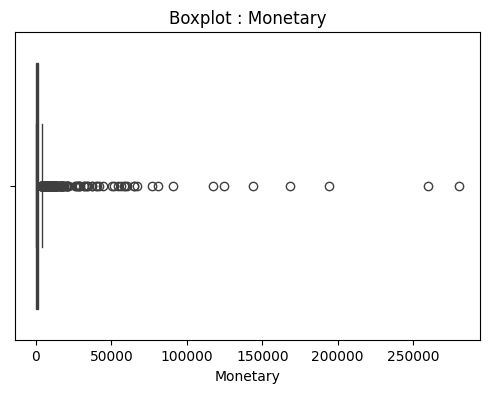

In [18]:
numeric_cols = df_rfm.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_rfm[col])
    plt.title(f"Boxplot : {col}")
    plt.xlabel(col)
    plt.show()

In [19]:
def cap_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df.loc[df[column] < lower_bound, column] = lower_bound
    df.loc[df[column] > upper_bound, column] = upper_bound

    return df
df_rfm = df_rfm.dropna(subset=["CustomerID"])
df_rfm = cap_outliers_iqr(df_rfm, "Recency")
df_rfm = cap_outliers_iqr(df_rfm, "Frequency")
df_rfm = cap_outliers_iqr(df_rfm, "Monetary")

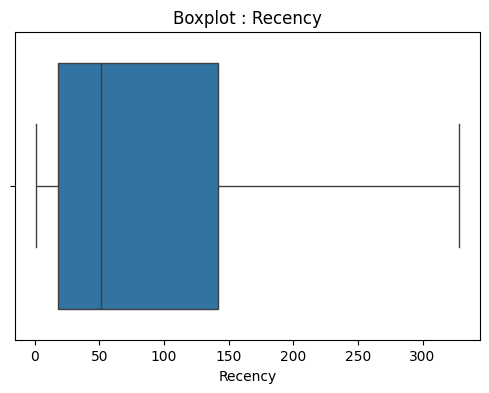

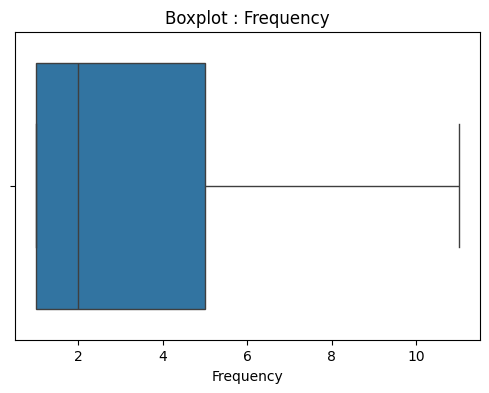

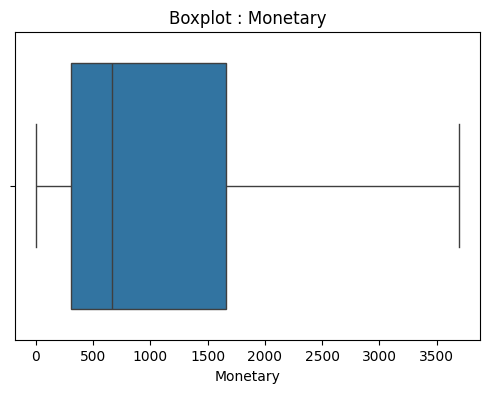

In [20]:
numeric_cols = df_rfm.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_rfm[col])
    plt.title(f"Boxplot : {col}")
    plt.xlabel(col)
    plt.show()

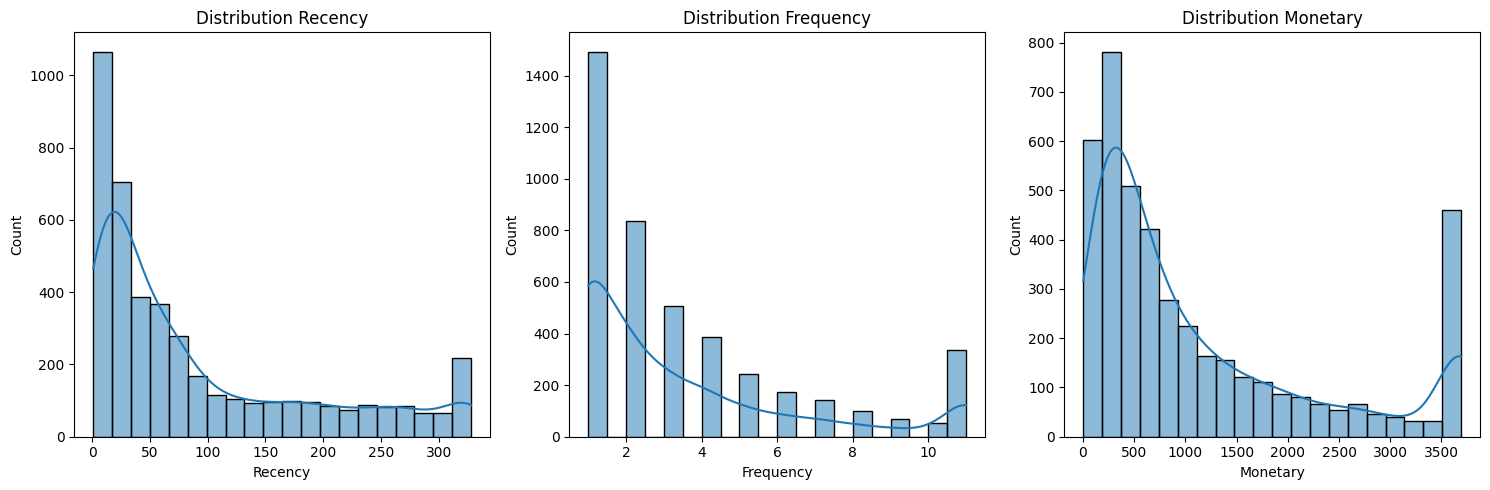

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df_rfm['Recency'], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution Recency")

sns.histplot(df_rfm['Frequency'], bins=20, kde=True, ax=axes[1])
axes[1].set_title("Distribution Frequency")

sns.histplot(df_rfm['Monetary'], bins=20, kde=True, ax=axes[2])
axes[2].set_title("Distribution Monetary")

plt.tight_layout()
plt.show()

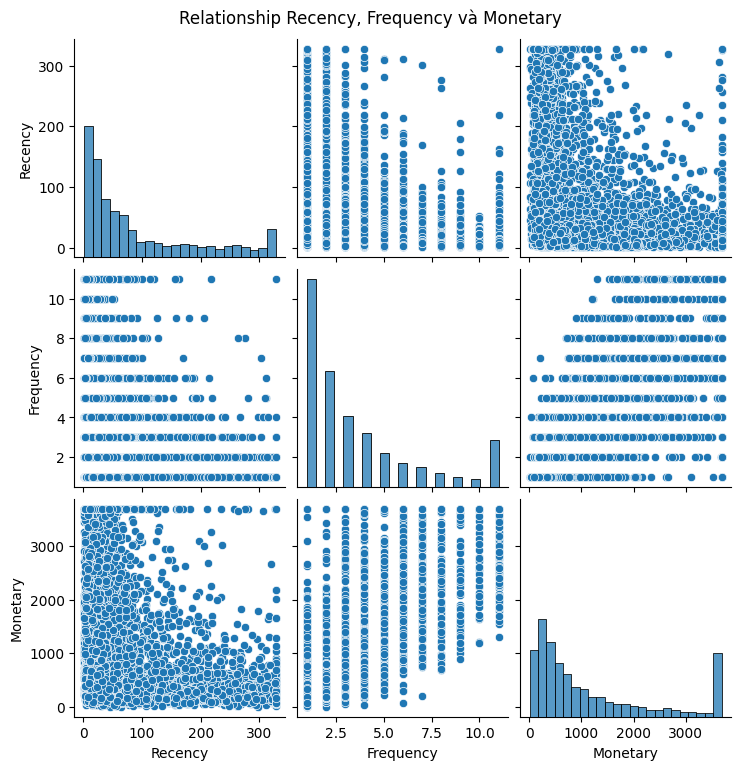

In [22]:
sns.pairplot(df_rfm[['Recency', 'Frequency', 'Monetary']])
plt.suptitle("Relationship Recency, Frequency và Monetary", y=1.02)
plt.show()

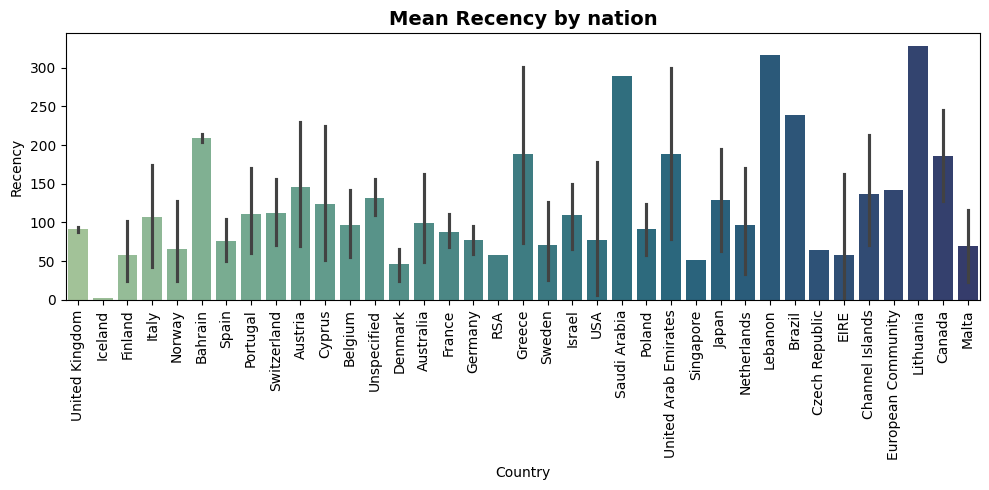

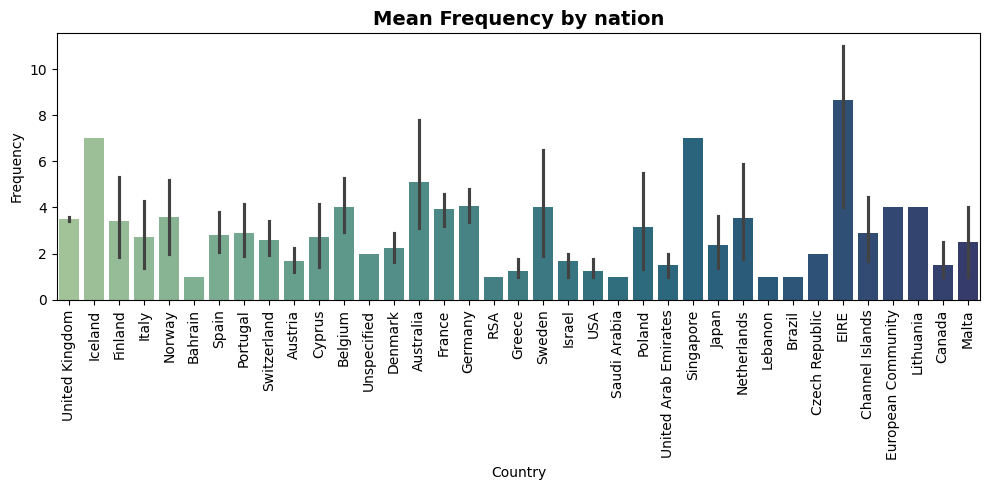

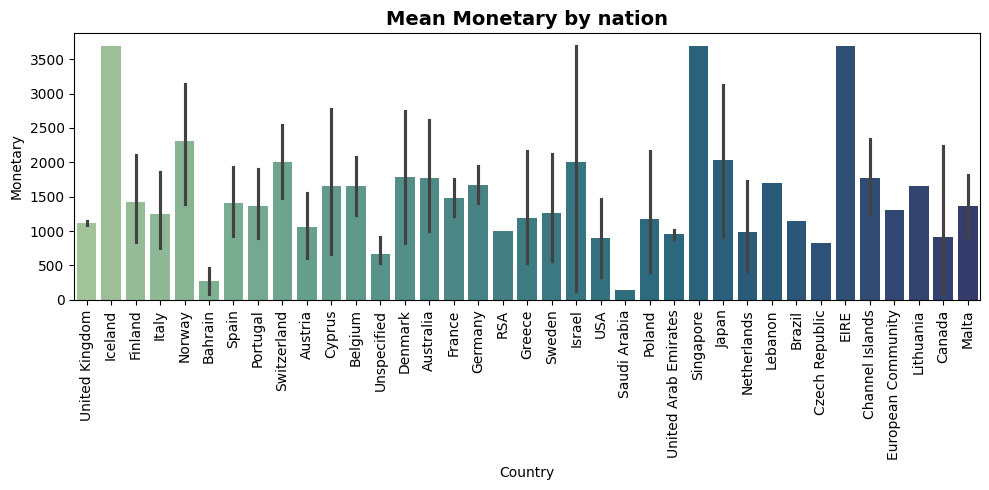

In [23]:
metrics = ['Recency', 'Frequency', 'Monetary']

for metric in metrics:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_rfm, x='Country', y=metric, palette='crest')
    plt.title(f"Mean {metric} by nation", fontsize=14, fontweight='bold')
    plt.xticks(rotation=90)
    plt.ylabel(metric)
    plt.xlabel("Country")
    plt.tight_layout()
    plt.show()

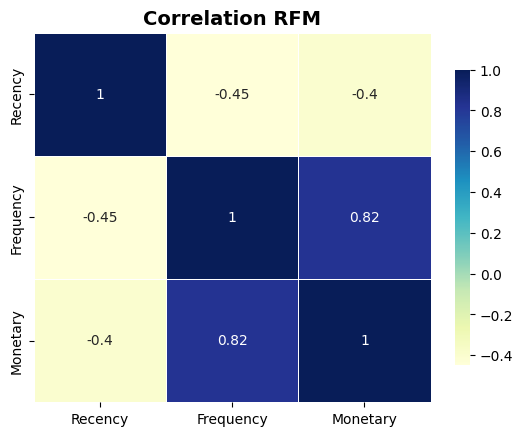

In [24]:
sns.heatmap(
    df_rfm[['Recency', 'Frequency', 'Monetary']].corr(),
    annot=True,
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title("Correlation RFM", fontsize=14, fontweight='bold')
plt.show()

In [25]:
df_rfm

,CustomerID,Recency,Frequency,Monetary,Country
0,12346.0,326,1,3691.77,United Kingdom
1,12347.0,2,7,3691.77,Iceland
2,12348.0,75,4,1797.24,Finland
3,12349.0,19,1,1757.55,Italy
4,12350.0,310,1,334.40,Norway
...,...,...,...,...,...
4333,18280.0,278,1,180.60,United Kingdom
4334,18281.0,181,1,80.82,United Kingdom
4335,18282.0,8,2,178.05,United Kingdom
4336,18283.0,4,11,2045.53,United Kingdom


In [26]:
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

In [27]:
df_rfm['RFM_score'] = df_rfm['R_Score'].astype(str) + df_rfm['F_Score'].astype(str) + df_rfm['M_Score'].astype(str)
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,Country,R_Score,F_Score,M_Score,RFM_score
0,12346.0,326,1,3691.77,United Kingdom,1,1,5,115
1,12347.0,2,7,3691.77,Iceland,5,5,5,555
2,12348.0,75,4,1797.24,Finland,2,4,4,244
3,12349.0,19,1,1757.55,Italy,4,1,4,414
4,12350.0,310,1,334.40,Norway,1,1,2,112


In [28]:
df_map.head()

,r_score,f_score,m_score,RFM_score,Segments
0,3,1,4,314,Big spender
1,3,1,5,315,Big spender
2,3,2,4,324,Big spender
3,3,2,5,325,Big spender
4,3,3,4,334,Big spender


In [29]:
df_map.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   r_score    125 non-null    int64 
 1   f_score    125 non-null    int64 
 2   m_score    125 non-null    int64 
 3   RFM_score  125 non-null    int64 
 4   Segments   125 non-null    object
dtypes: int64(4), object(1)
memory usage: 5.0+ KB


In [30]:
df_map["RFM_score"] = df_map["RFM_score"].astype("str")

In [31]:
df_full = df_rfm.merge(
    df_map[['RFM_score','Segments']], 
    on='RFM_score', 
    how='left'
)

df_full.head()

,CustomerID,Recency,Frequency,Monetary,Country,R_Score,F_Score,M_Score,RFM_score,Segments
0,12346.0,326,1,3691.77,United Kingdom,1,1,5,115,Losing Big spenders
1,12347.0,2,7,3691.77,Iceland,5,5,5,555,Champion
2,12348.0,75,4,1797.24,Finland,2,4,4,244,Losing Loyal Customers
3,12349.0,19,1,1757.55,Italy,4,1,4,414,Big spender
4,12350.0,310,1,334.40,Norway,1,1,2,112,Lost


# Khuyến nghị & Hướng hành động theo RFM Segments

## 1️⃣ Champions (555)
**Profile:** Mua thường xuyên, chi tiêu cao, gần đây vừa mua.  
**Goal:** Giữ họ ở nhóm này.  
**Hướng hành động:**
- Thưởng và ưu đãi đặc biệt (Rewards/Special offers)
- Khảo sát phản hồi, hỏi đánh giá (reviews)
- Thử nghiệm sản phẩm mới với họ (Test new product ideas)
- Khuyến khích giới thiệu bạn bè (Referral/Word of mouth)
- Gửi thư tay, email cá nhân hóa, giữ liên lạc thường xuyên

---

## 2️⃣ Loyal Customers ([3-5][4-5][1-5])
**Profile:** Chi tiêu đều, thường xuyên, phản hồi tốt với ưu đãi.  
**Goal:** Nâng họ thành Champions; tìm thêm khách hàng giống họ.  
**Hướng hành động:**
- Upsell các sản phẩm giá trị cao
- Hỏi đánh giá, khuyến nghị (reviews)
- Thử nghiệm sản phẩm mới, gửi ưu đãi hấp dẫn

---

## 3️⃣ Losing Loyal Customers ([1-2][4-5][1-5])
**Profile:** Trước đây sử dụng nhiều, gần đây giảm tương tác.  
**Goal:** Kéo họ về nhóm Loyal.  
**Hướng hành động:**
- Gọi điện hoặc gửi email cá nhân hóa, khảo sát feedback
- Ưu đãi đặc biệt để win-back
- Tặng quà nhỏ, gửi thư tay, chăm sóc đặc biệt

---

## 4️⃣ Promising ([4-5][2-3][2-3])
**Profile:** Khách mới gần đây, chi tiêu khá và mua nhiều lần.  
**Goal:** Giữ họ, nâng lên Loyal.  
**Hướng hành động:**
- Gửi chương trình loyalty, khuyến khích mua thêm
- Recommend sản phẩm bổ sung
- Gửi lời cảm ơn, chăm sóc cá nhân hóa

---

## 5️⃣ New Customers ([4-5][1-3][1-3])
**Profile:** Khách gần đây, mua 1–2 lần.  
**Goal:** Xây dựng mối quan hệ lâu dài.  
**Hướng hành động:**
- Gửi lời cảm ơn, hướng dẫn sử dụng, chia sẻ giá trị thương hiệu
- Hỗ trợ chủ động sau mua hàng

---

## 6️⃣ Warm Leads (411)
**Profile:** Mua 1–2 lần gần đây nhưng chi tiêu thấp.  
**Goal:** Nâng lên Promising.  
**Hướng hành động:**
- Nhắc nhở mua hàng, follow-up
- Upsell / cross-sell, giới thiệu ưu đãi

---

## 7️⃣ Cold Leads (311)
**Profile:** RFM thấp, có nguy cơ mất khách.  
**Goal:** Giữ tương tác, tránh mất khách, nâng lên Promising.  
**Hướng hành động:**
- Gợi ý sản phẩm phổ biến, giảm giá để khuyến khích mua lại
- Reconnect, hỏi feedback / khảo sát

---

## 8️⃣ Need Attention ([1-3][1-3][1-3])
**Profile:** RFM trung bình – thấp.  
**Goal:** Nâng lên Promising.  
**Hướng hành động:**
- Giới thiệu ưu đãi thời gian giới hạn
- Recommend sản phẩm bổ sung
- Chia sẻ thông tin hữu ích, tăng nhận diện thương hiệu
- Khảo sát phản hồi

---

## 9️⃣ Losing Big Spenders ([1-2][1-3][4-5])
**Profile:** Trước đây chi tiêu lớn nhưng gần đây ít tương tác.  
**Goal:** Kéo về Loyal.  
**Hướng hành động:**
- Gọi điện hoặc gửi email cá nhân
- Ưu đãi đặc biệt để win-back, tặng quà
- Khảo sát feedback

---

## 1️⃣0️⃣ Sleepers ([1-2][3-4])
**Profile:** Chi tiêu tốt nhưng lâu không mua.  
**Goal:** Kéo họ về Promising/Loyal.  
**Hướng hành động:**
- Reconnect bằng email cá nhân hóa
- Offer discounts, ưu đãi repurchase
- Hỏi feedback / khảo sát

---

## 1️⃣1️⃣ Lost ([1-2][1-2][1-2])
**Profile:** Mua ít, lâu không mua, RFM thấp nhất.  
**Goal:** Thử khôi phục sự quan tâm, nhưng không ưu tiên cao.  
**Hướng hành động:**
- Email khôi phục (holiday/Black Friday deals)
- Nhắc về thương hiệu và giá trị

---

## 1️⃣2️⃣ Big Spender ([3-5][1-3][4-5])
**Profile:** Chi tiêu nhiều và mua khá thường xuyên.  
**Goal:** Kéo về Loyal.  
**Hướng hành động:**
- Gọi điện, gửi email cá nhân, chăm sóc đặc biệt
- Ưu đãi đặc biệt để giữ chân, tặng quà
- Hỏi feedback, khảo sát

--- 


### 📌 Tóm tắt
1. **Champions & Big Spenders:** Giữ, ưu tiên chăm sóc cá nhân.  
2. **Loyal & Promising:** Nâng cấp lên hạng Champions.  
3. **Losing / Sleepers / Cold:** Giành lại tình cảm, kết nối lại.
4. **New / Warm Leads:** Chăm sóc để giữ tương tác.  
5. **Lost:** Thử khôi phục nếu có ưu đãi lớn, nhưng không tiêu tốn quá nhiều nguồn lực. 

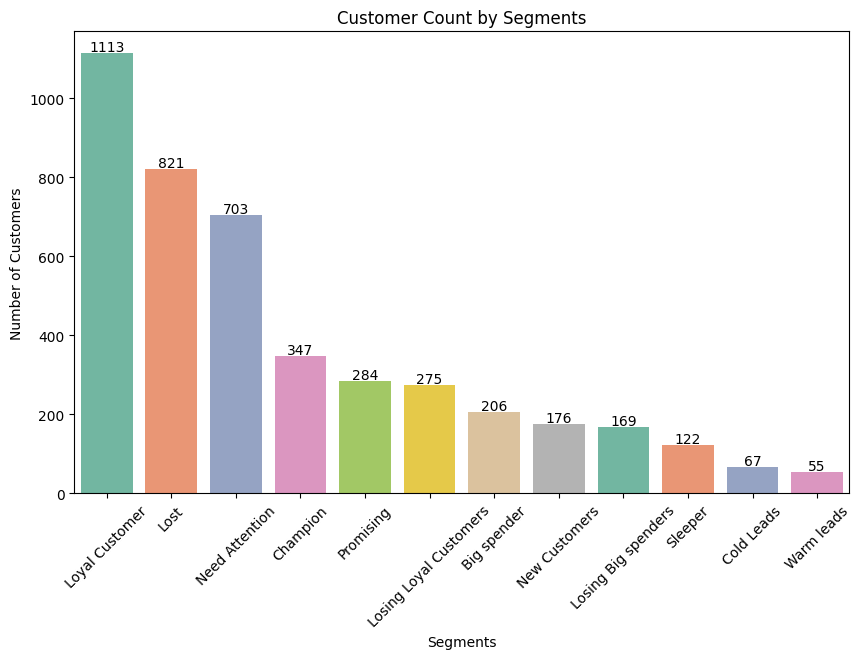

In [32]:
plt.figure(figsize=(10,6))
ax = sns.countplot(
    data=df_full, 
    x='Segments', 
    order=df_full['Segments'].value_counts().index,
    palette='Set2'
)


for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width()/2,  
        y=height + 5,               
        s=int(height),           
        ha='center'            
    )

plt.title('Customer Count by Segments')
plt.xlabel('Segments')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()


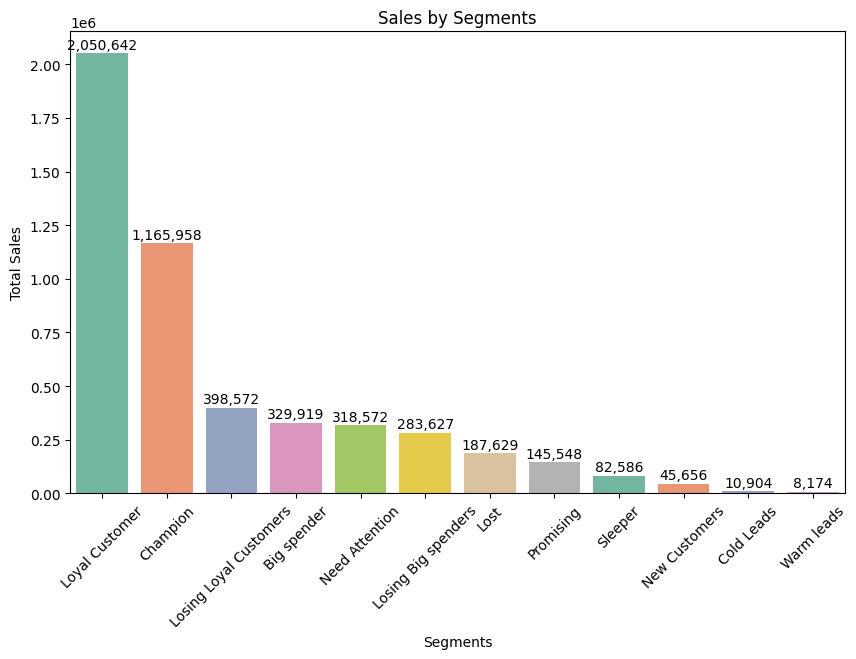

In [33]:
sales_by_segment = df_full.groupby('Segments')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=sales_by_segment.index, 
    y=sales_by_segment.values, 
    palette='Set2'
)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width()/2,  
        y=height + max(sales_by_segment.values)*0.01, 
        s=f"{height:,.0f}",
        ha='center'
    )

plt.title('Sales by Segments')
plt.xlabel('Segments')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


In [34]:
top5_countries = df_full['Country'].value_counts().head(5).index
df_top5 = df_full[df_full['Country'].isin(top5_countries)]
top5_countries

Index(['United Kingdom', 'Germany', 'France', 'Spain', 'Belgium'], dtype='object', name='Country')

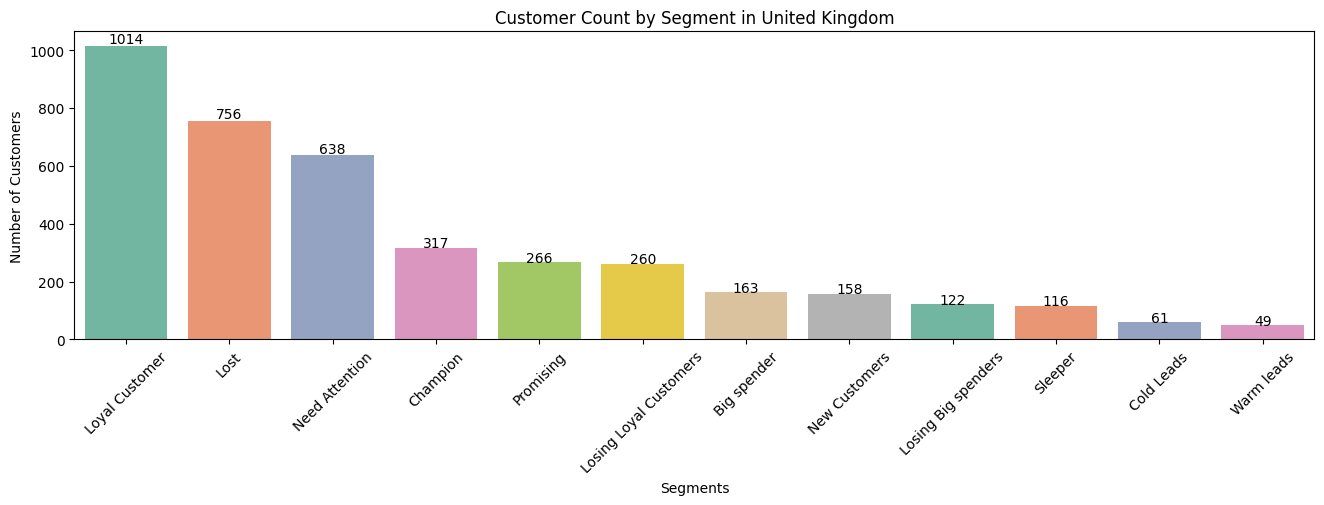

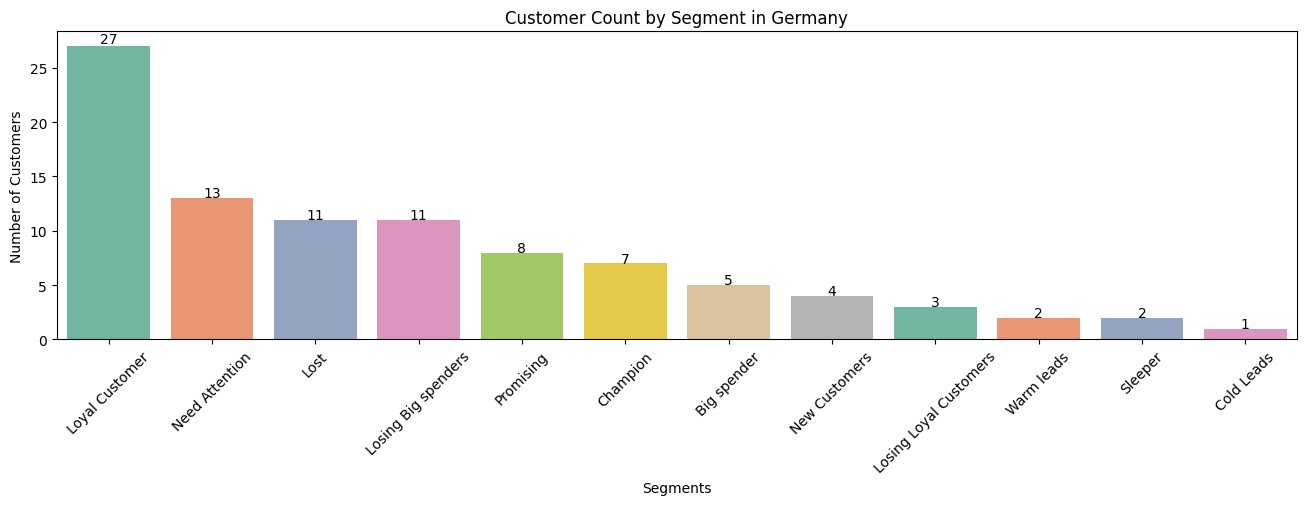

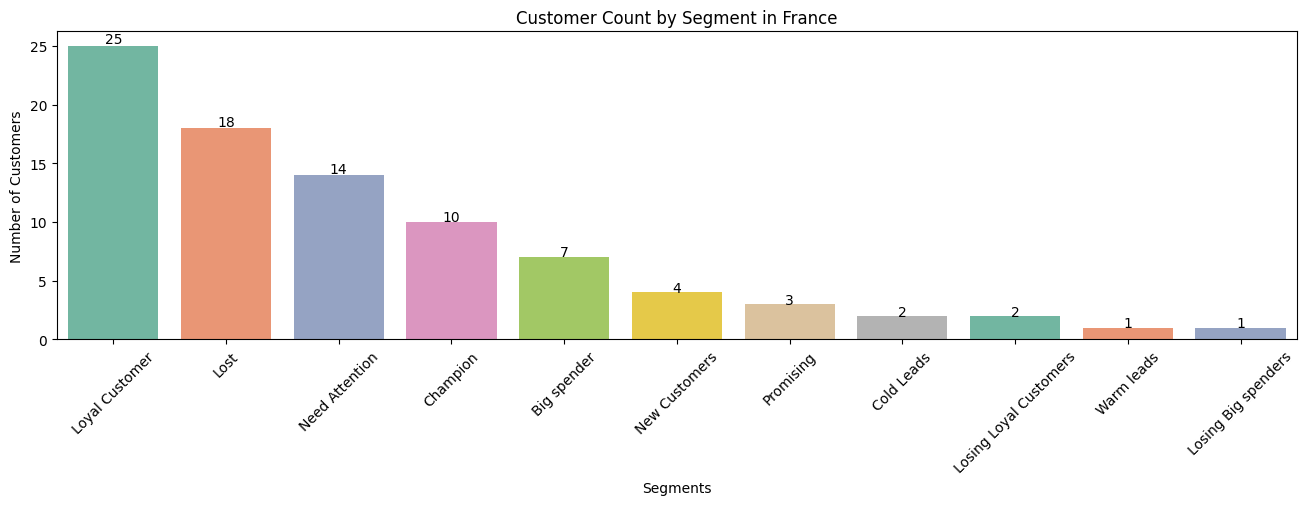

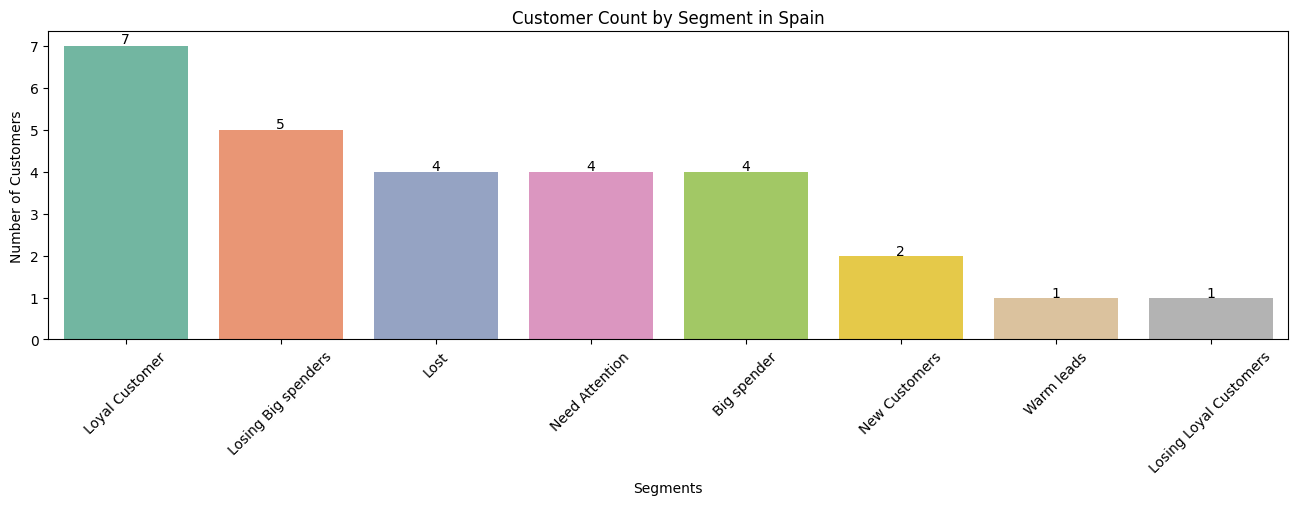

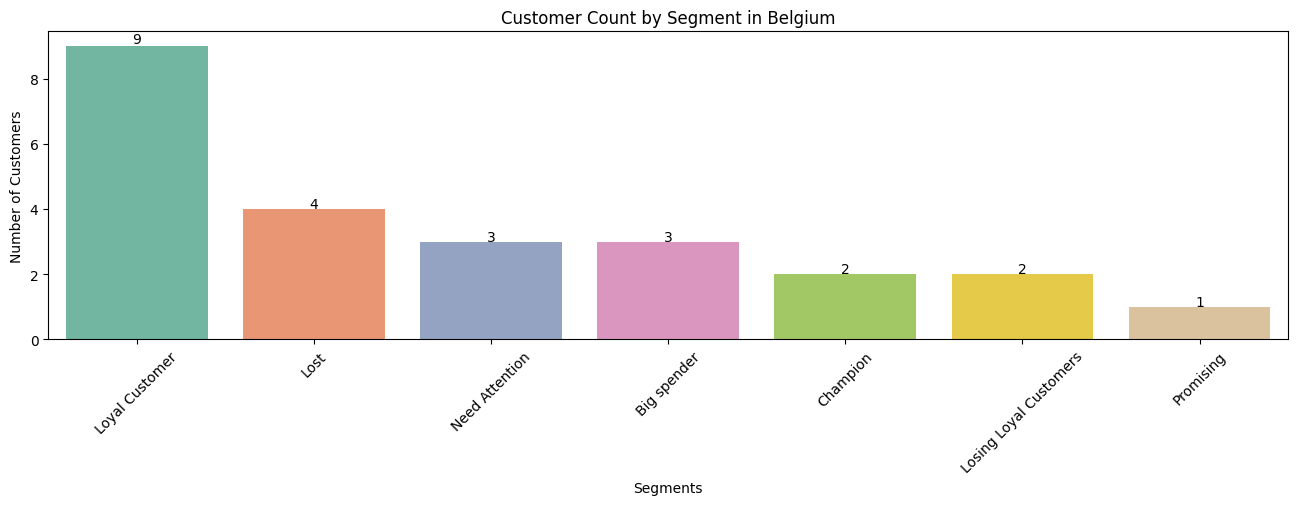

In [35]:
for country in top5_countries:
    plt.figure(figsize=(16,4))
    df_country = df_top5[df_top5['Country']==country]
    
    ax = sns.countplot(
        data=df_country,
        x='Segments',
        palette='Set2',
        order=df_country['Segments'].value_counts().index
    )
    
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            x=p.get_x() + p.get_width()/2, 
            y=height + 0.01*height,               
            s=int(height),         
            ha='center'
        )
    
    plt.title(f'Customer Count by Segment in {country}')
    plt.xlabel('Segments')
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=45)
    plt.show()


In [36]:
#end